In [55]:
import torch.nn as nn
from torchvision.models.detection.backbone_utils import BackboneWithFPN
from torchvision.models.detection.anchor_utils import AnchorGenerator
import torchvision
from torchvision.models.detection import FasterRCNN
from collections import OrderedDict

# Custom CNN Architecture
class CNNArchitecture(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        c3 = self.layer3(x)   # Output of layer3
        c4 = self.layer4(c3)  # Output of layer4
        return OrderedDict([("layer3", c3), ("layer4", c4)])  # Match return_layers
        

# Function to wrap the CNN with FPN
def create_backbone_with_fpn():
    body = CNNArchitecture()
    in_channels_list = [128, 256]  # Channels from layer3 and layer4
    out_channels = 256             # Desired FPN output channels

    return BackboneWithFPN(
        body,
        return_layers={"layer3": "0", "layer4": "1"},  # Use these keys in RoIAlign
        in_channels_list=in_channels_list,
        out_channels=out_channels
    )

# Define Anchor Generator
anchor_sizes = ((32, 64, 128), (64, 128, 256), (128, 256, 512))  # 3 levels
aspect_ratios = ((0.5, 1.0, 2.0),) * len(anchor_sizes)

anchor_generator = AnchorGenerator(
    sizes=anchor_sizes,
    aspect_ratios=aspect_ratios
)

# Final model constructor
def create_faster_rcnn_model(num_classes):
    backbone = create_backbone_with_fpn()

    box_roi_pool = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0', '1'],  # Must match return_layers values
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=box_roi_pool
    )

    return model


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = create_faster_rcnn_model(num_classes=265)  # 264 classes + background
model = model.to(device)
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (layer1): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer2): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer3): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer4): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3,

In [56]:
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor
import torchvision.transforms as T
import os

class CocoDetectionTransformWrapper(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super(CocoDetectionTransformWrapper, self).__init__(img_folder, ann_file)
        self._transforms = transforms

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for ann in anns:
            # COCO format: [x, y, width, height]
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])

        target_dict = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_id])
        }

        if self._transforms:
            img = self._transforms(img)

        return img, target_dict

transform = T.Compose([
    T.Resize((800, 800)),
    T.ToTensor()
])

train_dataset = CocoDetectionTransformWrapper(
    img_folder="/home/aojwang/data/yolo_dataset/train/images",
    ann_file="/home/aojwang/data/yolo_dataset/train/coco_train.json",
    transforms=transform
)

val_dataset = CocoDetectionTransformWrapper(
    img_folder="/home/aojwang/data/yolo_dataset/val/images",
    ann_file="/home/aojwang/data/yolo_dataset/val/coco_val.json",
    transforms=transform
)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [58]:
# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = create_faster_rcnn_model(num_classes=265)
model = model.to(device)

# Training loop
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for images, targets in train_loader:
        # Filter out targets with no boxes
        filtered_images = []
        filtered_targets = []
        for img, target in zip(images, targets):
            if target["boxes"].numel() != 0:
                filtered_images.append(img)
                filtered_targets.append(target)

        if len(filtered_images) == 0:
            continue
            
        images = [img.to(device) for img in filtered_images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in filtered_targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/10] Loss: {epoch_loss:.4f}")
    torch.save(model.state_dict(), f"fasterrcnnCustomCNN_epoch{epoch+1}.pth")

Epoch [1/10] Loss: 39640.1574
Epoch [2/10] Loss: 36276.1803
Epoch [3/10] Loss: 35445.2752
Epoch [4/10] Loss: 35153.4108
Epoch [5/10] Loss: 33676.1078
Epoch [7/10] Loss: 35083.8293
Epoch [8/10] Loss: 33837.9121
Epoch [9/10] Loss: 33740.0620
Epoch [10/10] Loss: 32733.6893


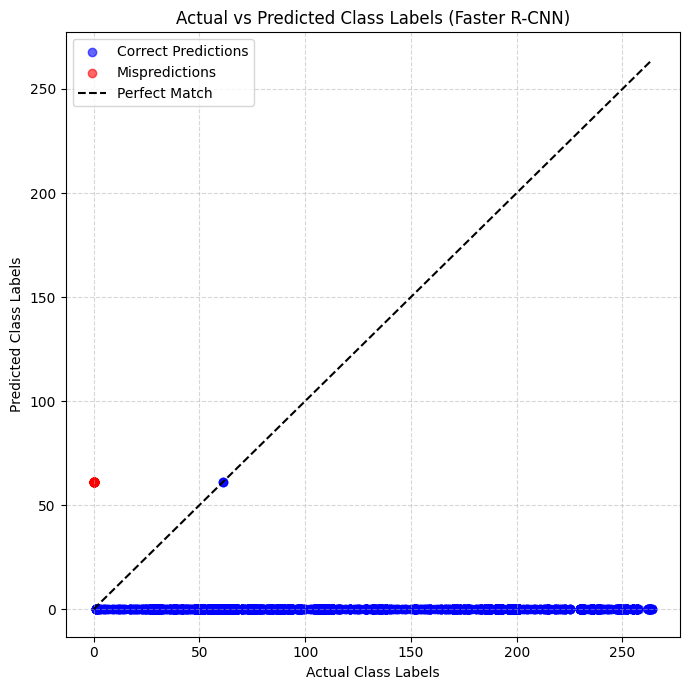

In [59]:
import torch
import matplotlib.pyplot as plt

# Lists to collect matched and mismatched predictions
actual_classes = []
predicted_classes = []
misactual_classes = []
mispredicted_classes = []

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i, output in enumerate(outputs):
            pred_labels = output['labels'].cpu().tolist()
            true_labels = targets[i]['labels'].cpu().tolist()

            if len(pred_labels) == 0 and len(true_labels) > 0:
                # All false negatives
                actual_classes.extend(true_labels)
                predicted_classes.extend([0] * len(true_labels))
                continue

            if len(true_labels) == 0 and len(pred_labels) > 0:
                # All false positives
                misactual_classes.extend([0] * len(pred_labels))
                mispredicted_classes.extend(pred_labels)
                continue

            # Match predictions to ground truths one-to-one (basic matching)
            min_len = min(len(pred_labels), len(true_labels))
            for j in range(min_len):
                if pred_labels[j] == true_labels[j]:
                    actual_classes.append(true_labels[j])
                    predicted_classes.append(pred_labels[j])
                else:
                    actual_classes.append(true_labels[j])
                    predicted_classes.append(0)  # mispredicted class shown as 0
                    misactual_classes.append(0)
                    mispredicted_classes.append(pred_labels[j])

            # Extra predicted labels (false positives)
            if len(pred_labels) > min_len:
                misactual_classes.extend([0] * (len(pred_labels) - min_len))
                mispredicted_classes.extend(pred_labels[min_len:])

            # Extra ground truth labels (false negatives)
            if len(true_labels) > min_len:
                actual_classes.extend(true_labels[min_len:])
                predicted_classes.extend([0] * (len(true_labels) - min_len))

# Plotting
plt.figure(figsize=(7, 7))
plt.scatter(actual_classes, predicted_classes, alpha=0.6, color='blue', label='Correct Predictions')
plt.scatter(misactual_classes, mispredicted_classes, alpha=0.6, color='red', label='Mispredictions')

# Diagonal reference line
all_values = actual_classes + predicted_classes + misactual_classes + mispredicted_classes
if all_values:
    min_val, max_val = min(all_values), max(all_values)
else:
    min_val, max_val = 0, 1
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Match')

# Labels and title
plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels (Faster R-CNN)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
